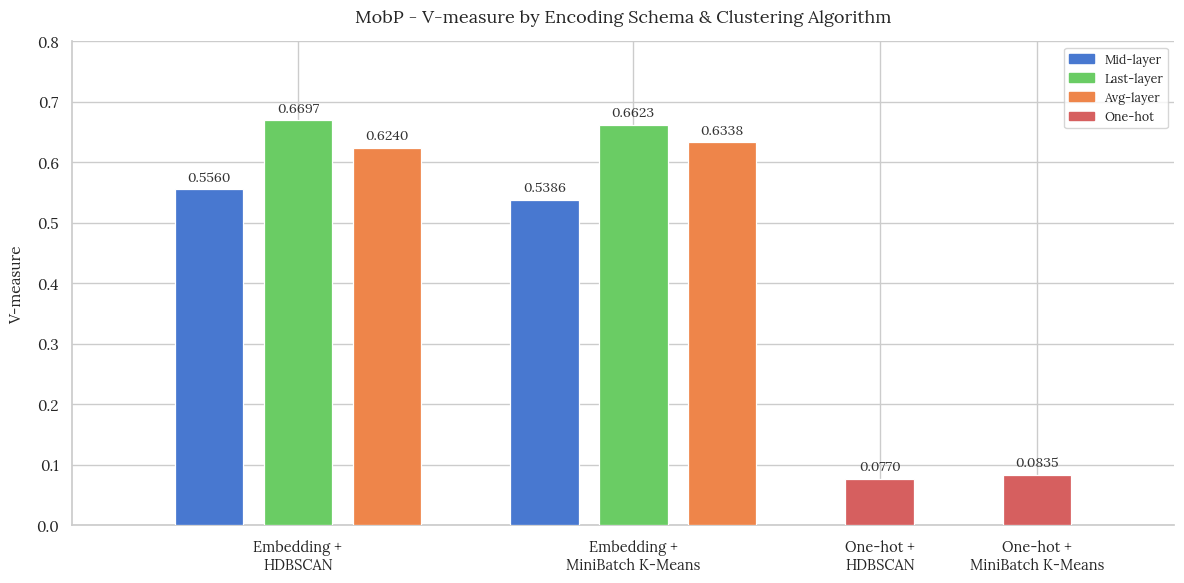

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import requests
import numpy as np
import seaborn as sns

# ── Data ──────────────────────────────────────────────────────────────────────
groups = [
    "Embedding +\nHDBSCAN",
    "Embedding +\nMiniBatch K-Means",
    "One-hot +\nHDBSCAN",
    "One-hot +\nMiniBatch K-Means",
]

data = {
    "Embedding +\nHDBSCAN": [
        (0.5560, "Mid"),
        (0.6697, "Last"),
        (0.6240, "Avg"),
    ],
    "Embedding +\nMiniBatch K-Means": [
        (0.5386, "Mid"),
        (0.6623, "Last"),
        (0.6338, "Avg"),
    ],
    "One-hot +\nHDBSCAN": [
        (0.0770, "N/A"),
    ],
    "One-hot +\nMiniBatch K-Means": [
        (0.0835, "N/A"),
    ],
}

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font="arial")

url = "https://github.com/google/fonts/raw/refs/heads/main/ofl/lora/Lora%5Bwght%5D.ttf"
response = requests.get(url, allow_redirects=True)
font_path = "/tmp/Lora-Regular.ttf"

with open(font_path, "wb") as f:
    f.write(response.content)

fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Lora"

palette   = sns.color_palette("muted")
COLORS    = [palette[0], palette[2], palette[1]]   # Mid / Last / Avg  (blue, green, orange)
ONEHOT_COLOR = palette[3]                           # red-ish for one-hot

# ── Layout constants ───────────────────────────────────────────────────────────
BAR_W      = 0.10
WITHIN_GAP = 0.13
INTER_GAP  = 0.18

def group_width(n):
    return (n - 1) * WITHIN_GAP + BAR_W

# ── Compute group centers (boundary-based spacing) ────────────────────────────
group_centers = []
for g_idx, group_name in enumerate(groups):
    n = len(data[group_name])
    if g_idx == 0:
        center = (n - 1) * WITHIN_GAP / 2
    else:
        prev_n     = len(data[groups[g_idx - 1]])
        prev_right = group_centers[-1] + (prev_n - 1) * WITHIN_GAP / 2 + BAR_W / 2
        cur_left   = prev_right + INTER_GAP
        center     = cur_left + (n - 1) * WITHIN_GAP / 2
    group_centers.append(center)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for g_idx, group_name in enumerate(groups):
    bars      = data[group_name]
    n         = len(bars)
    center    = group_centers[g_idx]
    offsets   = np.arange(n) * WITHIN_GAP - (n - 1) * WITHIN_GAP / 2
    is_onehot = group_name.startswith("One-hot")

    for b_idx, (v_measure, layer) in enumerate(bars):
        x     = center + offsets[b_idx]
        color = ONEHOT_COLOR if is_onehot else COLORS[b_idx]

        ax.bar(x, v_measure, width=BAR_W, color=color,
               edgecolor="white", linewidth=0.9, zorder=3)

        # value label on top
        ax.text(x, v_measure + 0.009, f"{v_measure:.4f}",
                ha="center", va="bottom", fontsize=10, color="#333333")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(group_centers)
ax.set_xticklabels(groups, fontsize=10.5)

margin = 0.15
ax.set_xlim(group_centers[0]  - group_width(3) / 2 - margin,
            group_centers[-1] + group_width(1) / 2 + margin)

ax.set_ylabel("V-measure", fontsize=11, labelpad=8)
ax.set_ylim(0, 0.800)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

# seaborn grid is already on; clean up spines
sns.despine(left=False, bottom=False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

ax.set_title("MobP - V-measure by Encoding Schema & Clustering Algorithm",
             fontsize=13, fontweight="bold", pad=14)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLORS[0],   label="Mid-layer"),
    mpatches.Patch(color=COLORS[1],   label="Last-layer"),
    mpatches.Patch(color=COLORS[2],   label="Avg-layer"),
    mpatches.Patch(color=ONEHOT_COLOR, label="One-hot"),
]
ax.legend(handles=legend_handles, loc="upper right",
          fontsize=9, framealpha=0.8, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig('Bar chart of MobP - V-Measure.png')
plt.show()